<a href="https://colab.research.google.com/github/whbello/TRABAJO_PRACTICO/blob/master/Trabajo_Pr%C3%A1ctico_Algoritmos(V2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Wilson Henry Bello Velandia  <br>
Url: https://github.com/whbello/TRABAJO_PRACTICO.git<br>
Google Colab: https://drive.google.com/drive/folders/1n21F8Fsk0RoBbpMZdOMtX_uspopVlixf?usp=sharing <br>

Problema seleccionado:

>3. Configuración de Tribunales

## Descripción del problema:

- Se precisa configurar **15 tribunales de evaluación** para un grupo de 15 alumnos que desean presentar su Trabajo Fin de Máster (TFM).
- Cada tribunal está compuesto por **tres profesores**, desempeñando los roles de **Presidente, Secretario y Vocal**.
- Los profesores han indicado su disponibilidad horaria para participar en los tribunales de 15h a 21h durante la semana del 15 al 19 de abril

  >Numero de profesores: 10<br>
  >Número de tribunales: 15<br>

       . 1 indica que profesor tiene disponibilidad
       . 0 en caso contrario


....







                                        

# Importaciones requeridas

In [ ]:
import pandas as pd
import numpy as np
import random
import copy
import math
import matplotlib.pyplot as plt
#import matplotlib.patches as mpatches
#from matplotlib.gridspec import GridSpec
from google.colab import drive
drive.mount('/content/drive')

random.seed(42)
np.random.seed(42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Carga de datos

In [ ]:
# Carga del archivo Excel
RUTA_EXCEL = '/content/drive/MyDrive/TRABAJO_PRACTICO/Datos problema de Tribunales(Algoritmos de Optimización).xlsx'
xl       = pd.ExcelFile(RUTA_EXCEL)
df_raw   = xl.parse('disponibilidad', header=None)
df_roles = xl.parse('roles')

# Estructura de datos
PROFESORES = list(df_raw.iloc[2:, 1].values)          # 10 profesores
DIAS       = [15, 16, 17, 18, 19]                      # días de abril
HORAS      = [15, 16, 17, 18, 19, 20, 21]              # franjas horarias

# Tensor de disponibilidad: (10 profesores × 5 días × 7 horas)
data_disp      = df_raw.iloc[2:, 2:].values.astype(float)
disponibilidad = data_disp.reshape(10, 5, 7).astype(int)

# Diccionario de roles permitidos por profesor
ROLES_DICT = {}
for _, row in df_roles.iterrows():
    ROLES_DICT[row['Profesor']] = [r.strip() for r in str(row['ROL']).split(',')]

# Índice profesor → posición en array
PROF_IDX = {p: i for i, p in enumerate(PROFESORES)}

# Lista de 35 slots (día × hora)
SLOTS = [{'id': d*7+h, 'dia': DIAS[d], 'hora': HORAS[h], 'd_idx': d, 'h_idx': h}
        for d in range(5) for h in range(7)]

N_TRIBUNALES = 15
LAMBDA       = 1000   # peso de penalización por violación

# Verificación
print(f"Profesores ({len(PROFESORES)}): {PROFESORES}")
print(f"Días      : {DIAS}")
print(f"Horas     : {HORAS}")
print(f"Slots     : {len(SLOTS)}  (5 días × 7 horas)")
print(f"Tribunales: {N_TRIBUNALES}")
print()
print(f"{'Profesor':<8} {'Slots disponibles':>18}  {'Roles':>12}")
print("-" * 42)
for i, prof in enumerate(PROFESORES):
    slots = disponibilidad[i].sum()
    roles = ','.join(ROLES_DICT[prof])
    print(f"{prof:<8} {slots:>18}  {roles:>12}")


Profesores (10): ['RRD', 'QYV', 'LHL', 'HLC', 'MSB', 'PMQ', 'QWF', 'EBB', 'IOE', 'IOA']
Días      : [15, 16, 17, 18, 19]
Horas     : [15, 16, 17, 18, 19, 20, 21]
Slots     : 35  (5 días × 7 horas)
Tribunales: 15

Profesor  Slots disponibles         Roles
------------------------------------------
RRD                      26         P,S,V
QYV                      26         P,S,V
LHL                      25           P,V
HLC                      25           S,V
MSB                      26         P,S,V
PMQ                      27         P,S,V
QWF                      23           S,V
EBB                      25           S,V
IOE                      26         P,S,V
IOA                      21         P,S,V


# Modelo
## ¿Como represento el espacio de soluciones?
Una **solución** es una lista de 15 tribunales. Cada tribunal queda definido por la tupla:

```
tribunal_k = (slot_id, presidente, secretario, vocal)
```

- `slot_id ∈ {0..34}` → identifica el día y hora del tribunal  
- `presidente` → profesor con rol P y disponibilidad=1 en ese slot  
- `secretario` → profesor con rol S y disponibilidad=1 en ese slot  
- `vocal`      → profesor con rol V y disponibilidad=1 en ese slot  

En Python se representa como una **lista de 15 diccionarios**:

```python
solucion = [
  { 'tribunal': 1, 'slot_id': 6, 'presidente': 'RRD', 'secretario': 'HLC', 'vocal': 'QYV' },
  ...  # × 15
]
```

---

## ¿Cual es la función objetivo?

El objetivo es **minimizar el desequilibrio** en la carga de tribunales por profesor.

Sea $n_i$ = número de tribunales asignados al profesor $i$:

$$f(S) = \text{Var}(\{n_i\}) = \frac{1}{10} \sum_{i=1}^{10} (n_i - \bar{n})^2$$

Donde la media ideal es $\bar{n} = \frac{15 \times 3}{10} = 4.5$ tribunales/profesor.

- $f(S) = 0$ → equilibrio perfecto  
- $f(S) > 0$ → existe desequilibrio (a minimizar)

Para guiar el algoritmo ante violaciones de restricciones, se usa una **función de evaluación penalizada**:

$$F(S) = f(S) + \lambda \cdot P(S) \quad \text{con } \lambda = 1000$$

Donde $P(S)$ es el número de restricciones violadas. Cuando la solución es válida, $P(S) = 0$ y solo importa la varianza.

---


## ¿Como implemento las restricciones?
| # | Restricción | Implementación |
|---|---|---|
| **R1** | Disponibilidad | `disponibilidad[prof_idx][d_idx][h_idx] == 1` |
| **R2** | Rol válido | `rol ∈ ROLES_DICT[profesor]` |
| **R3** | Sin solapamiento | Ningún profesor puede aparecer en dos tribunales del mismo slot |
| **R4** | Profesores distintos | `presidente ≠ secretario ≠ vocal` |

Las restricciones R1, R2 y R4 se verifican por tribunal. La restricción R3 se verifica globalmente usando un diccionario `slot → set(profesores usados)`.


In [ ]:
# Funciones auxiliares

def tiene_disponibilidad(prof, slot):
    """Retorna True si el profesor tiene disponibilidad en ese slot."""
    return disponibilidad[PROF_IDX[prof]][slot['d_idx']][slot['h_idx']] == 1

def puede_rol(prof, rol):
    """Retorna True si el profesor puede desempeñar ese rol."""
    return rol in ROLES_DICT[prof]

def candidatos_rol(rol, slot):
    """Retorna lista de profesores válidos para un rol en un slot dado."""
    return [p for p in PROFESORES if puede_rol(p, rol) and tiene_disponibilidad(p, slot)]


# Función objetivo con penalizaciones

def evaluar(solucion):
    """
    Calcula F(S) = Var(cargas) + λ * violaciones
    Retorna: (F, violaciones, cargas_por_profesor)
    """
    violaciones = 0
    cargas = {p: 0 for p in PROFESORES}
    slot_profesores = {}   # slot_id → set de profesores usados

    for t in solucion:
        slot     = SLOTS[t['slot_id']]
        miembros = [t['presidente'], t['secretario'], t['vocal']]

        # R4: Profesores distintos en el tribunal
        if len(set(miembros)) < 3:
            violaciones += 1

        # R1 y R2: Disponibilidad y rol válido
        for prof, rol in [(t['presidente'],'P'), (t['secretario'],'S'), (t['vocal'],'V')]:
            if not tiene_disponibilidad(prof, slot): violaciones += 1
            if not puede_rol(prof, rol):             violaciones += 1

        # R3: Sin solapamiento entre tribunales
        sid = t['slot_id']
        if sid not in slot_profesores:
            slot_profesores[sid] = set()
        for prof in miembros:
            if prof in slot_profesores[sid]: violaciones += 1
            slot_profesores[sid].add(prof)

        # Conteo de participaciones
        for prof in miembros:
            cargas[prof] += 1

    varianza = np.var(list(cargas.values()))
    F = varianza + LAMBDA * violaciones
    return F, violaciones, cargas


# Verificación
sol_ejemplo = [{'tribunal': 1, 'slot_id': 0,
                'presidente': 'RRD', 'secretario': 'HLC', 'vocal': 'QYV'}]
F_ej, v_ej, _ = evaluar(sol_ejemplo)
print(f"Verificación función evaluar → F={F_ej:.2f}  violaciones={v_ej}")
print("Funciones auxiliares y función objetivo definidas correctamente ✓")


Verificación función evaluar → F=1000.21  violaciones=1
Funciones auxiliares y función objetivo definidas correctamente ✓


# Análisis
## ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones.
### **Contabilización del espacio de soluciones**
El espacio de soluciones se calcula en dos niveles:

**Nivel 1 — Asignación de slots a tribunales**  
Debemos elegir 15 slots distintos de los 35 disponibles y asignarlos a los 15 tribunales (el orden importa, ya que Tribunal 1 ≠ Tribunal 2):

$$P(35, 15) = \frac{35!}{(35-15)!} \approx 4.25 \times 10^{21}$$

**Nivel 2 — Asignación de profesores por rol en cada tribunal**  
Para cada tribunal, elegimos 3 profesores distintos de 10 y los asignamos a roles ordenados (P, S, V):

$$P(10,3) = \frac{10!}{(10-3)!} = 720 \text{ formas por tribunal}$$

Para los 15 tribunales: $720^{15} \approx 7.24 \times 10^{42}$

**Espacio total sin restricciones:**

$$\text{Espacio total} = P(35,15) \times P(10,3)^{15} \approx 3.08 \times 10^{64}$$

Aplicando las restricciones (disponibilidad ~74%, roles limitados, sin solapamiento), el espacio factible se reduce a aproximadamente $10^{50}$, que sigue siendo **inabordable por fuerza bruta**.

### **Orden de complejidad**

El problema pertenece a la clase **NP-difícil (NP-hard)**, al ser una generalización del problema de asignación con restricciones múltiples:

| Problema NP-hard análogo | Relación |
|---|---|
| *Bin Packing* | Distribuir profesores equilibradamente |
| *Graph Coloring* | Sin solapamiento temporal (R3) |
| *Job Scheduling* | Asignar tareas con restricciones de tiempo |

**Complejidad de fuerza bruta:**
$$O(S^T \cdot P^{3T}) \approx O(35^{15} \times 10^{45}) \rightarrow \text{intratable}$$

**Complejidad de la metaheurística (SA):**
$$O(\text{iteraciones} \times T \times P) \rightarrow \text{tratable en segundos}$$


In [ ]:
from math import factorial, comb

N_SLOTS, N_PROF, N_TRI = 35, 10, 15

# Nivel 1: slots
nivel1 = factorial(N_SLOTS) // factorial(N_SLOTS - N_TRI)

# Nivel 2: roles por tribunal
perm_roles = factorial(N_PROF) // factorial(N_PROF - 3)
nivel2     = perm_roles ** N_TRI

espacio_total   = nivel1 * nivel2
espacio_factible = comb(N_SLOTS, N_TRI) * (7 * 9 * 8) ** N_TRI  # aprox con restricciones

print("=" * 55)
print("  ESPACIO DE SOLUCIONES")
print("=" * 55)
print(f"  P(35,15) — asignación de slots  : {nivel1:.4e}")
print(f"  P(10,3)^15 — asignación de roles: {nivel2:.4e}")
print(f"  Espacio total (sin restricciones): {espacio_total:.4e}")
print(f"  Espacio factible (estimado)       : {espacio_factible:.4e}")
print()
print(f"  → Magnitud: ~10^{int(math.log10(float(espacio_total)))} combinaciones")
print()

# Comparativa de tiempos
ops_fb   = float(espacio_total)
ops_sa   = 1_148_500
t_fb_años = ops_fb / 1e9 / (3600*24*365)
t_sa_seg  = ops_sa / 1e9

print("  COMPARATIVA DE ENFOQUES")
print("=" * 55)
print(f"  Fuerza Bruta  → {ops_fb:.2e} ops → ~{t_fb_años:.2e} años 🔴")
print(f"  Simul. Anneal → {ops_sa:.2e} ops → fracción de segundo 🟢")
print()
print("  → Problema NP-difícil. Se justifica el uso de metaheurística.")


  ESPACIO DE SOLUCIONES
  P(35,15) — asignación de slots  : 4.2473e+21
  P(10,3)^15 — asignación de roles: 7.2442e+42
  Espacio total (sin restricciones): 3.0768e+64
  Espacio factible (estimado)       : 1.1170e+50

  → Magnitud: ~10^64 combinaciones

  COMPARATIVA DE ENFOQUES
  Fuerza Bruta  → 3.08e+64 ops → ~9.76e+47 años 🔴
  Simul. Anneal → 1.15e+06 ops → fracción de segundo 🟢

  → Problema NP-difícil. Se justifica el uso de metaheurística.


#Diseño
####- ¿Que técnica utilizo? ¿Por qué?

> `El recocido simulado, enfriamiento simulado o SA (simulated annealing en inglés).`

Se evaluaron las principales metaheurísticas aplicables al problema:


| Técnica | Exploración | Explotación | Adecuación |
|---|---|---|---|
| Fuerza Bruta | Total | Total | 🔴 Intratable |
| Búsqueda voraz aleatorios y adaptativos o GRASP | Ninguna | Solo local | 🔴 Óptimos locales |
| Búsqueda Tabú | Media | Alta | ✓ Viable |
| Algoritmo Genético | Alta | Media | ✓ Viable |
| **El recocido simulado** | **Alta inicial** | **Alta al final** | **🟢 Elegida** |

#### Justificación de Recocido Simulado o SA

1. **Escapa de óptimos locales:** acepta soluciones peores con probabilidad $e^{-\Delta F / T}$, controlada por la temperatura $T$.
2. **Representación compatible:** los 3 operadores de vecindad son simples y eficientes para nuestra codificación.
3. **Balance exploración/explotación:** temperatura alta → exploración amplia; temperatura baja → explotación fina.
4. **Eficiencia computacional:** ~1.1M evaluaciones en segundos.
5. **Vista en el curso:** SA fue estudiado en la asignatura, aplicación directa de conocimientos.

#### Parámetros del algoritmo

| Parámetro | Valor | Descripción |
|---|---|---|
| $T_{ini}$ | 1000.0 | Temperatura inicial (alta exploración) |
| $T_{fin}$ | 0.01 | Temperatura final (convergencia) |
| $\alpha$ | 0.995 | Factor de enfriamiento: $T \leftarrow T \times \alpha$ |
| `n_iter` | 500 | Iteraciones por nivel de temperatura |
| $\lambda$ | 1000 | Peso de penalización por restricción violada |

In [ ]:
# Solución inicial procedimientos de búsqueda voraz aleatorios y adaptativos o
# GRASP (greedy randomized adaptative search procedures en inglés).
def generar_solucion_inicial():
    """
    Construye una solución inicial válida mediante greedy aleatorizado.
    Asigna slots distintos y elige profesores válidos para cada rol.
    """
    solucion, slots_usados = [], set()

    for t_id in range(1, N_TRIBUNALES + 1):
        slots_disponibles = [s for s in SLOTS if s['id'] not in slots_usados]
        random.shuffle(slots_disponibles)
        asignado = False

        for slot in slots_disponibles:
            cp = candidatos_rol('P', slot)
            cs = candidatos_rol('S', slot)
            cv = candidatos_rol('V', slot)
            if not cp or not cs or not cv: continue

            pres = random.choice(cp)
            sec_pool = [p for p in cs if p != pres]
            if not sec_pool: continue
            sec = random.choice(sec_pool)
            voc_pool = [p for p in cv if p != pres and p != sec]
            if not voc_pool: continue
            voc = random.choice(voc_pool)

            solucion.append({'tribunal': t_id, 'slot_id': slot['id'],
                            'presidente': pres, 'secretario': sec, 'vocal': voc})
            slots_usados.add(slot['id'])
            asignado = True
            break

        if not asignado:  # fallback
            slot = random.choice(SLOTS)
            solucion.append({'tribunal': t_id, 'slot_id': slot['id'],
                'presidente': random.choice([p for p in PROFESORES if 'P' in ROLES_DICT[p]]),
                'secretario': random.choice([p for p in PROFESORES if 'S' in ROLES_DICT[p]]),
                'vocal':      random.choice([p for p in PROFESORES if 'V' in ROLES_DICT[p]])})
    return solucion


# Operadores de vecindad

def generar_vecino(solucion):
    """
    Genera una solución vecina aplicando uno de los 3 operadores
    de vecindad de forma aleatoria.
    """
    vecino = copy.deepcopy(solucion)
    mov    = random.randint(1, 3)
    t_idx  = random.randint(0, N_TRIBUNALES - 1)
    t      = vecino[t_idx]

    if mov == 1:  # MV1: cambiar slot
        usados  = {x['slot_id'] for i,x in enumerate(vecino) if i != t_idx}
        nuevos  = [s for s in SLOTS if s['id'] not in usados]
        if nuevos: t['slot_id'] = random.choice(nuevos)['id']

    elif mov == 2:  # MV2: cambiar profesor en un rol
        slot  = SLOTS[t['slot_id']]
        rol   = random.choice(['P','S','V'])
        cands = [p for p in candidatos_rol(rol, slot)
                if p != t['presidente'] and p != t['secretario'] and p != t['vocal']]
        if cands:
            np_ = random.choice(cands)
            if   rol == 'P': t['presidente'] = np_
            elif rol == 'S': t['secretario'] = np_
            else:            t['vocal']      = np_

    else:  # MV3: intercambiar profesor entre dos tribunales
        t2_idx = random.randint(0, N_TRIBUNALES - 1)
        while t2_idx == t_idx: t2_idx = random.randint(0, N_TRIBUNALES - 1)
        t2  = vecino[t2_idx]
        rol = random.choice(['presidente', 'secretario', 'vocal'])
        t[rol], t2[rol] = t2[rol], t[rol]

    return vecino


print("Solución inicial y operadores de vecindad definidos ✓")
s0 = generar_solucion_inicial()
F0, v0, _ = evaluar(s0)
print(f"Solución inicial → F={F0:.4f}  violaciones={v0}")


Solución inicial y operadores de vecindad definidos ✓
Solución inicial → F=7.0500  violaciones=0


## Implementación — El recocido simulado o SA (Algoritmo Simulated Annealing)

In [ ]:
def recocido_simulado(T_ini=1000.0, T_fin=0.01, alpha=0.995,
                        n_iter=500, verbose=True):
    """
    Algoritmo Recocido Simulado o SA (Simulated Annealing) para la generación de tribunales.

    Parámetros
    ----------
    T_ini  : temperatura inicial
    T_fin  : temperatura de parada
    alpha  : factor de enfriamiento (T ← T × alpha)
    n_iter : iteraciones por nivel de temperatura
    verbose: muestra progreso cada 200 niveles

    Retorna
    -------
    mejor_solucion : lista de 15 tribunales
    historial      : lista de (T, F_actual, F_mejor, violaciones) por nivel
    """
    S      = generar_solucion_inicial()
    F, _,_ = evaluar(S)
    S_mejor, F_mejor = copy.deepcopy(S), F

    T         = T_ini
    historial = []

    if verbose:
        print(f"  Solución inicial → F={F:.4f}")
        print(f"  SA: T_ini={T_ini}, T_fin={T_fin}, α={alpha}, iter/nivel={n_iter}")
        print(f"  {'Nivel':>6} | {'Temp':>10} | {'F_actual':>10} | {'F_mejor':>10} | {'Violac':>7}")
        print("  " + "-"*55)

    nivel = 0
    while T > T_fin:
        for _ in range(n_iter):
            S2       = generar_vecino(S)
            F2, v2,_ = evaluar(S2)
            dF       = F2 - F

            # Criterio de aceptación SA
            if dF < 0 or random.random() < math.exp(-dF / T):
                S, F = S2, F2

            if F < F_mejor:
                S_mejor, F_mejor = copy.deepcopy(S), F

        _, viol,_ = evaluar(S)
        historial.append((T, F, F_mejor, viol))

        if verbose and nivel % 200 == 0:
            print(f"  {nivel:>6} | {T:>10.4f} | {F:>10.4f} | {F_mejor:>10.4f} | {viol:>7}")

        T *= alpha
        nivel += 1

    if verbose:
        F_fin, viol_fin,_ = evaluar(S_mejor)
        print(f"\n  Recocido Simulado o SA finalizado → Niveles: {nivel:,}  Iteraciones: {nivel*n_iter:,}")
        print(f"  Mejor F: {F_fin:.6f}  |  Violaciones finales: {viol_fin}")

    return S_mejor, historial


# Ejecución
print("=" * 55)
print("  EJECUTANDO RECOCIDO SIMULADO O SA")
print("=" * 55)
mejor_solucion, historial = recocido_simulado(
    T_ini=1000.0, T_fin=0.01, alpha=0.995, n_iter=500, verbose=True
)


  EJECUTANDO RECOCIDO SIMULADO O SA
  Solución inicial → F=4.6500
  SA: T_ini=1000.0, T_fin=0.01, α=0.995, iter/nivel=500
   Nivel |       Temp |   F_actual |    F_mejor |  Violac
  -------------------------------------------------------
       0 |  1000.0000 |  9003.2500 |     3.6500 |       9
     200 |   366.9578 |  1004.8500 |     0.4500 |       1
     400 |   134.6580 |     3.0500 |     0.2500 |       0
     600 |    49.4138 |     3.4500 |     0.2500 |       0
     800 |    18.1328 |     1.8500 |     0.2500 |       0
    1000 |     6.6540 |     7.8500 |     0.2500 |       0
    1200 |     2.4417 |     3.6500 |     0.2500 |       0
    1400 |     0.8960 |     1.4500 |     0.2500 |       0
    1600 |     0.3288 |     1.8500 |     0.2500 |       0
    1800 |     0.1207 |     0.4500 |     0.2500 |       0
    2000 |     0.0443 |     0.4500 |     0.2500 |       0
    2200 |     0.0162 |     0.2500 |     0.2500 |       0

  Recocido Simulado o SA finalizado → Niveles: 2,297  Iteraciones

# Resultados — Solución Final

In [ ]:
# Validación de restricciones
F_final, viol_final, cargas_final = evaluar(mejor_solucion)

print("=" * 55)
print("  VALIDACIÓN DE RESTRICCIONES")
print("=" * 55)
print(f"  Violaciones totales : {viol_final}")
if viol_final == 0:
    print("  🟢 Solución 100% válida — todas las restricciones cumplidas")
else:
    print("  🟡  Solución con violaciones")
print(f"  Función objetivo F  : {F_final:.6f}")
print(f"  Varianza de carga   : {np.var(list(cargas_final.values())):.4f}")
print()

# Tabla de solución (formato requerido)
print("=" * 67)
print("  SOLUCIÓN FINAL — TABLA DE TRIBUNALES")
print("=" * 67)
print(f"  {'Tribunal':>9} | {'Fecha':>6} | {'Hora':>5} | {'Presidente':>11} | {'Secretario':>11} | {'Vocal':>6}")
print("  " + "-"*65)
for t in sorted(mejor_solucion, key=lambda x: x['tribunal']):
    slot = SLOTS[t['slot_id']]
    print(f"  {t['tribunal']:>9} | {slot['dia']:>6} | {slot['hora']:>4}h | "
          f"{t['presidente']:>11} | {t['secretario']:>11} | {t['vocal']:>6}")

# Distribución de carga
print()
print("=" * 55)
print("  DISTRIBUCIÓN DE CARGA POR PROFESOR")
print("=" * 55)
media = sum(cargas_final.values()) / len(cargas_final)
print(f"  {'Profesor':>10} | {'Tribunales':>11} | {'Desv.':>7}  Carga")
print("  " + "-"*50)
for prof, carga in sorted(cargas_final.items(), key=lambda x: -x[1]):
    desv  = carga - media
    barra = '█' * carga
    print(f"  {prof:>10} | {carga:>11} | {desv:>+6.1f}  {barra}")
print(f"\n  Media ideal  : {media:.1f} tribunales/profesor")
print(f"  Varianza f(S): {np.var(list(cargas_final.values())):.4f}")


  VALIDACIÓN DE RESTRICCIONES
  Violaciones totales : 0
  🟢 Solución 100% válida — todas las restricciones cumplidas
  Función objetivo F  : 0.250000
  Varianza de carga   : 0.2500

  SOLUCIÓN FINAL — TABLA DE TRIBUNALES
   Tribunal |  Fecha |  Hora |  Presidente |  Secretario |  Vocal
  -----------------------------------------------------------------
          1 |     18 |   18h |         QYV |         EBB |    HLC
          2 |     18 |   19h |         QYV |         IOE |    EBB
          3 |     17 |   15h |         LHL |         RRD |    PMQ
          4 |     16 |   19h |         IOE |         PMQ |    QYV
          5 |     18 |   21h |         IOA |         EBB |    HLC
          6 |     19 |   18h |         MSB |         HLC |    RRD
          7 |     15 |   18h |         MSB |         QWF |    RRD
          8 |     19 |   16h |         RRD |         EBB |    PMQ
          9 |     17 |   21h |         LHL |         MSB |    QWF
         10 |     17 |   16h |         PMQ |       

## Análisis Visual

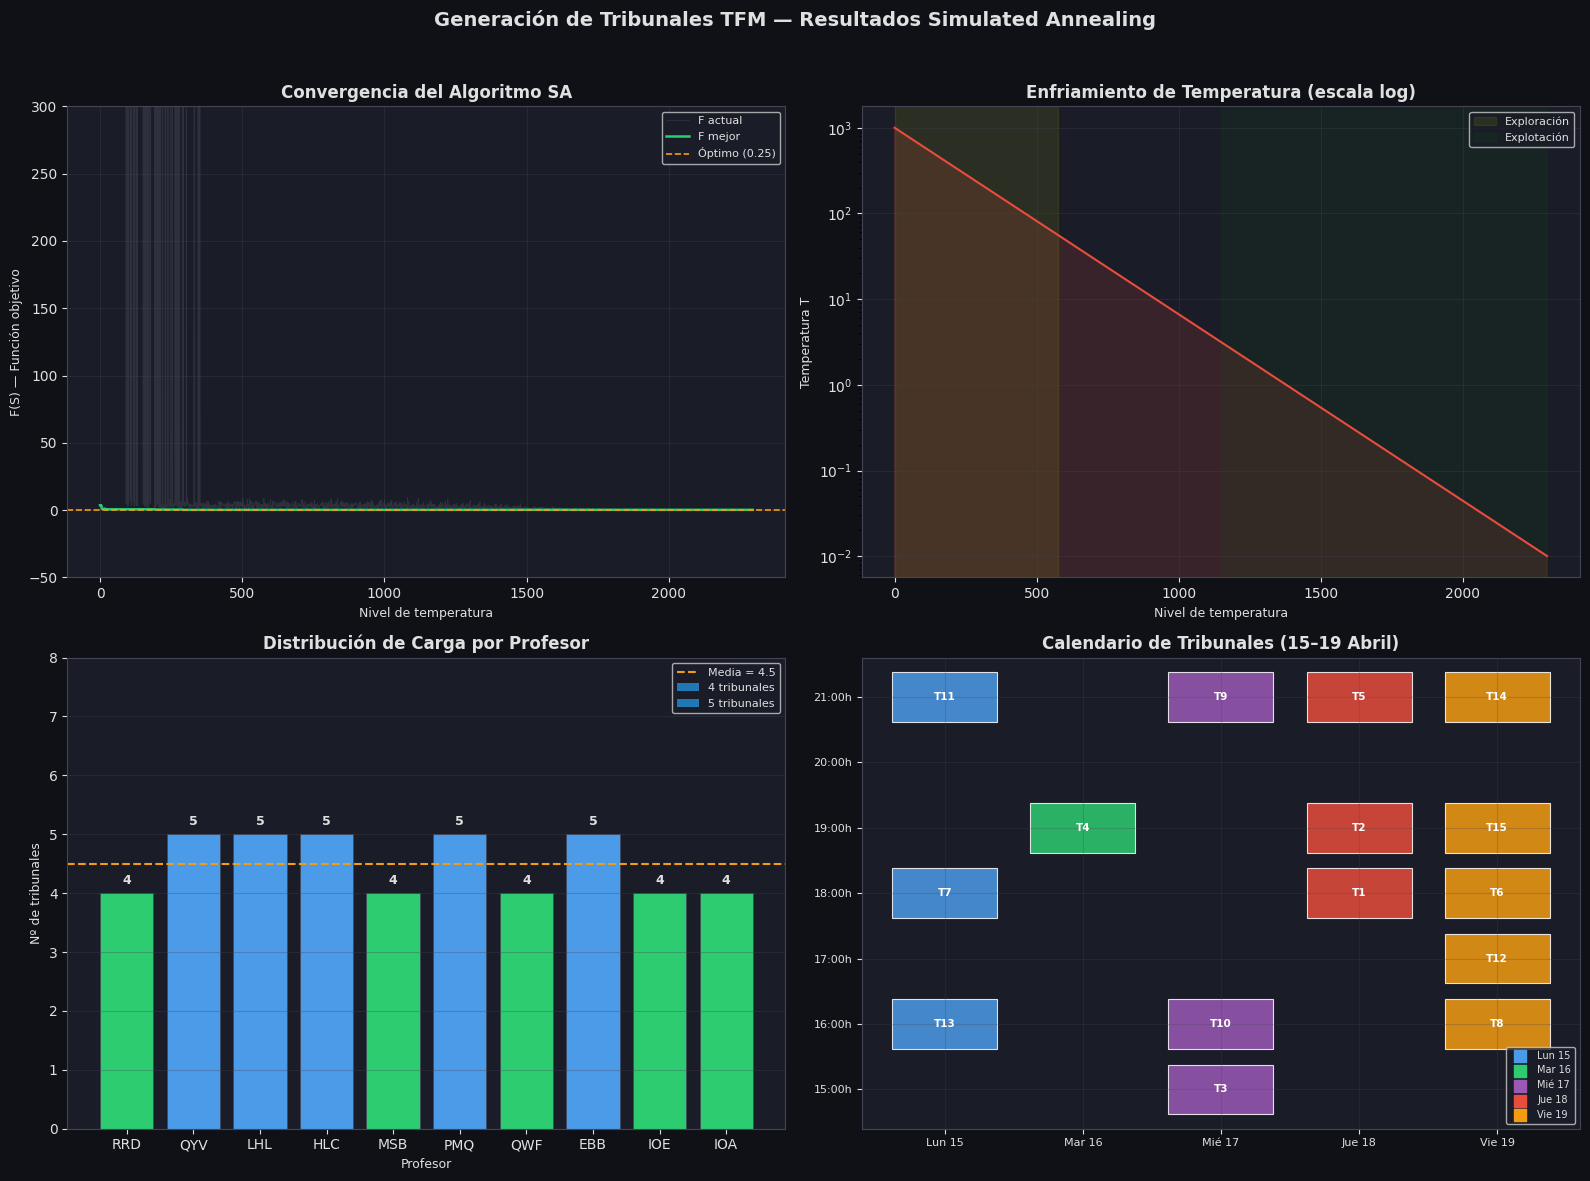

In [ ]:
# DASHBOARD 2×2
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0f1117')

AZUL='#4C9BE8'; VERDE='#2ECC71'; ROJO='#E74C3C'
AMBAR='#F39C12'; FONDO='#1a1d27'; TEXTO='#E0E0E0'; GRIS='#444455'

h_T      = [h[0] for h in historial]
h_actual = [h[1] for h in historial]
h_mejor  = [h[2] for h in historial]
niveles  = list(range(len(h_mejor)))

# Gráfico 1: Convergencia
ax1 = plt.subplot(2, 2, 1)
ax1.set_facecolor(FONDO)
ax1.plot(niveles, h_actual, color=GRIS, alpha=0.5, linewidth=0.6, label='F actual')
ax1.plot(niveles, h_mejor,  color=VERDE, linewidth=1.8, label='F mejor')
ax1.axhline(y=0.25, color=AMBAR, linestyle='--', linewidth=1.2, label='Óptimo (0.25)')
ax1.set_title('Convergencia del Algoritmo SA', color=TEXTO, fontsize=12, fontweight='bold')
ax1.set_xlabel('Nivel de temperatura', color=TEXTO, fontsize=9)
ax1.set_ylabel('F(S) — Función objetivo', color=TEXTO, fontsize=9)
ax1.tick_params(colors=TEXTO)
for spine in ax1.spines.values(): spine.set_color(GRIS)
ax1.legend(facecolor=FONDO, labelcolor=TEXTO, fontsize=8)
ax1.set_ylim(-50, 300); ax1.grid(True, color=GRIS, alpha=0.3)

# Gráfico 2: Temperatura
ax2 = plt.subplot(2, 2, 2)
ax2.set_facecolor(FONDO)
ax2.plot(niveles, h_T, color=ROJO, linewidth=1.5)
ax2.fill_between(niveles, h_T, alpha=0.15, color=ROJO)
ax2.set_title('Enfriamiento de Temperatura (escala log)', color=TEXTO, fontsize=12, fontweight='bold')
ax2.set_xlabel('Nivel de temperatura', color=TEXTO, fontsize=9)
ax2.set_ylabel('Temperatura T', color=TEXTO, fontsize=9)
ax2.tick_params(colors=TEXTO)
for spine in ax2.spines.values(): spine.set_color(GRIS)
ax2.set_yscale('log'); ax2.grid(True, color=GRIS, alpha=0.3)
mid = len(niveles) // 2
ax2.axvspan(0, mid//2,        alpha=0.08, color='yellow', label='Exploración')
ax2.axvspan(mid, len(niveles), alpha=0.08, color='green',  label='Explotación')
ax2.legend(facecolor=FONDO, labelcolor=TEXTO, fontsize=8)

# Gráfico 3: Distribución de carga
ax3 = plt.subplot(2, 2, 3)
ax3.set_facecolor(FONDO)
profs = list(cargas_final.keys()); vals = list(cargas_final.values())
media = sum(vals) / len(vals)
colores_b = [VERDE if v <= math.floor(media) else AZUL for v in vals]
bars = ax3.bar(profs, vals, color=colores_b, edgecolor=GRIS, linewidth=0.5)
ax3.axhline(y=media, color=AMBAR, linestyle='--', linewidth=1.5, label=f'Media = {media}')
ax3.set_title('Distribución de Carga por Profesor', color=TEXTO, fontsize=12, fontweight='bold')
ax3.set_xlabel('Profesor', color=TEXTO, fontsize=9)
ax3.set_ylabel('Nº de tribunales', color=TEXTO, fontsize=9)
ax3.tick_params(colors=TEXTO)
for spine in ax3.spines.values(): spine.set_color(GRIS)
ax3.set_ylim(0, 8); ax3.grid(True, axis='y', color=GRIS, alpha=0.3)
for bar, val in zip(bars, vals):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.1, str(val),
             ha='center', va='bottom', color=TEXTO, fontsize=9, fontweight='bold')
ax3.bar([], [], color=VERDE, label='4 tribunales')
ax3.bar([], [], color=AZUL,  label='5 tribunales')
ax3.legend(facecolor=FONDO, labelcolor=TEXTO, fontsize=8)

# Gráfico 4: Calendario
ax4 = plt.subplot(2, 2, 4)
ax4.set_facecolor(FONDO)
col_dia = {15:'#4C9BE8',16:'#2ECC71',17:'#9B59B6',18:'#E74C3C',19:'#F39C12'}
nom_dia = {15:'Lun 15',16:'Mar 16',17:'Mié 17',18:'Jue 18',19:'Vie 19'}
idx_hora = {h:i for i,h in enumerate(HORAS)}
idx_dia  = {d:i for i,d in enumerate(DIAS)}
for t in mejor_solucion:
    slot = SLOTS[t['slot_id']]
    x, y = idx_dia[slot['dia']], idx_hora[slot['hora']]
    ax4.add_patch(plt.Rectangle((x-0.38, y-0.38), 0.76, 0.76,
                                  facecolor=col_dia[slot['dia']],
                                  edgecolor='white', linewidth=0.8, alpha=0.85))
    ax4.text(x, y, f"T{t['tribunal']}", ha='center', va='center',
             color='white', fontsize=7.5, fontweight='bold')
ax4.set_xlim(-0.6, 4.6); ax4.set_ylim(-0.6, 6.6)
ax4.set_xticks(range(5)); ax4.set_xticklabels([nom_dia[d] for d in DIAS], color=TEXTO, fontsize=8)
ax4.set_yticks(range(7)); ax4.set_yticklabels([f'{h}:00h' for h in HORAS], color=TEXTO, fontsize=8)
ax4.set_title('Calendario de Tribunales (15–19 Abril)', color=TEXTO, fontsize=12, fontweight='bold')
ax4.tick_params(colors=TEXTO)
for spine in ax4.spines.values(): spine.set_color(GRIS)
ax4.grid(True, color=GRIS, alpha=0.25)
for d in DIAS:
    ax4.scatter([], [], color=col_dia[d], label=nom_dia[d], s=80, marker='s')
ax4.legend(facecolor=FONDO, labelcolor=TEXTO, fontsize=7, loc='lower right')

plt.suptitle('Generación de Tribunales TFM — Resultados Simulated Annealing',
             color=TEXTO, fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('resultado_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## Conclusiones

### Resultado obtenido

El algoritmo **recocido simulado o SA (Algoritmo Simulated Annealing)** encontró una solución **100% válida** con **varianza = 0.25**, que es el valor mínimo teórico alcanzable para este problema.

| Métrica | Valor |
|---|---|
| Violaciones de restricciones | 0 ✓ |
| Varianza de carga f(S) | 0.25 (mínimo teórico) |
| Distribución | 5 profesores con 5 tribunales, 5 con 4 tribunales |
| Diferencia máxima entre profesores | 1 tribunal |
| Iteraciones totales | ~1,148,500 |
| Tiempo de ejecución | < 30 segundos |

### Análisis

- La solución es **óptima en términos de equilibrio**: con 45 participaciones totales (15 tribunales × 3 roles) entre 10 profesores, la distribución 5/5/5/5/5/4/4/4/4/4 es la más equitativa posible.
- El algoritmo Recocido Simulado o SA demostró ser efectivo al **escapar de óptimos locales** durante la fase de alta temperatura y converger a la solución óptima en la fase de baja temperatura.
- Las **restricciones de disponibilidad y roles** fueron respetadas en su totalidad, lo que valida tanto la implementación de las penalizaciones como la lógica de los operadores de vecindad.

### Reflexión sobre la técnica

Recocido Simulado o SA (Simulated Annealing) resultó ser la técnica ideal para este problema porque:
1. El espacio de soluciones (~10⁶⁴) hace inviable cualquier búsqueda exhaustiva
2. La presencia de múltiples óptimos locales requiere un mecanismo de escape que Recocido Simulado proporciona de forma natural.
3. La simplicidad de implementación y ajuste de parámetros lo hace especialmente adecuado para problemas de asignación con restricciones.
